In [1]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import gysela_utilities as gys_utils;
import rprof_utilities as utils;

# Styling.
plt.style.use("ggplot");

In [2]:
# Test inputs - delete when done!
directory_path = "/zhisongqu_data/seth/GYSELA/raw/fresh_batch_10.0/DN_FLUXDRIVEN_ITG_TEST";
data_arrays = reader.fetch_rprof_data(directory_path, dataset = "QGC_perp_vE_r_FSavg");

Found 1201 files in the directory. Beginning compilation...
Compiled data from 1000 files...
Finished compiling data from all files in the directory.


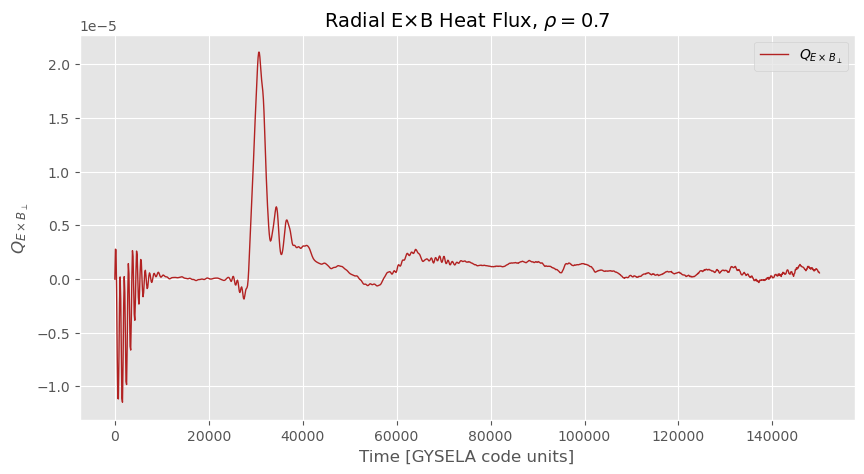

In [3]:
def plot_radial_heat_flux_time_series(rprof_list, dt_diag, effective_radius = None, log_scale = False):	
	# Stack into (time, r) array.
	heat_flux_series = xr.concat(rprof_list, dim = "time");
	
	if effective_radius is not None:
		heat_flux_series = gys_utils.slice_at_effective_radius(heat_flux_series, effective_radius);
	
	#time_range = utils.generate_time_range_by_series(particle_flux_series, dt_diag);
	time_range = gys_utils.generate_time_range_by_series(heat_flux_series, dt_diag);

	# Figure plotting logic.
	operation = plt.semilogy if log_scale else plt.plot;
	rho_label = f"$\\rho = {effective_radius}$" if effective_radius is not None else "all radii";
	plt.figure(figsize=(10, 5));
	operation(time_range, heat_flux_series, color="firebrick", lw = 1.0, label = r"$Q_{E \times B_{\perp}}$");
	plt.title(f"Radial E×B Heat Flux, {rho_label}", fontsize = 14);
	plt.xlabel("Time [GYSELA code units]", fontsize = 12);
	plt.ylabel(r"$Q_{E \times B_{\perp}}$", fontsize = 12);
	plt.legend();
	plt.show();

plot_radial_heat_flux_time_series(data_arrays, dt_diag = 125, effective_radius = 0.7, log_scale = False);